# **REINVENT4를 이용한 de novo 분자 설계**
이 실습을 마치면 다음을 할 수 있습니다:

*  분자 생성을 위한 강화학습(RL)의 기본 원리를 이해한다
*  REINVENT4가 RL로 분자 물성을 최적화하는 방식을 설명한다
*  다양한 분자 설계 과제에 맞게 REINVENT4를 설정한다
*  sigma와 diversity filter가 학습에 미치는 영향을 분석한다
*  sampling·scoring 워크플로우로 생성 분자를 평가한다
*  특정 신약개발 타깃을 위한 전이학습(transfer learning)을 구현한다


먼저 REINVENT4를 내려받고 필요한 패키지를 설치합니다. 설치가 끝나면 Colab이 세션을 재시작해야 하므로, 아래 셀을 계속 진행하기 전에 재시작(restart)을 확인해 주세요. 설치에는 약 5분 정도 걸립니다.

In [1]:
# ============================================================
#  REINVENT4 내려받기 + 설치   (Colab Python 3.13 기준)
# ============================================================
import os

# ── 1) 코드·prior 내려받기 — 이미 있으면 건너뜁니다 (다시 실행해도 안전) ──
if not os.path.exists("/content/REINVENT4"):
    !wget -q -O /content/reinvent4.zip https://uni-muenster.sciebo.de/s/T6PHKsMkJfBxa3F/download
    !unzip -q /content/reinvent4.zip -d /content/

%cd /content/REINVENT4

# ── 2) 의존 패키지 ────────────────────────────────────────────────
#  reinvent_requirements.txt 는 Python 3.10 시절 버전으로 고정돼 있어
#  현재 Colab(Python 3.13)에서는 pillow·numpy 등이 소스 빌드에 실패합니다.
#  아래는 Python 3.13에서 동작을 확인한 조합입니다.
%pip install -q "mmpdb>=2.1,<3" tomli tenacity xxhash apted molvs funcy \
                python-dotenv pyyaml requests tqdm pydantic matplotlib \
                rdkit tensorboard "numpy<3" "pandas<3" pillow mols2grid

#  torch·torchvision은 Colab에 이미 들어 있습니다.
#  없다는 오류가 나면 아래 줄의 주석을 푸세요.
# %pip install -q torch==2.7.1 torchvision==0.22.1 --index-url https://download.pytorch.org/whl/cpu

# ── 3) reinvent 패키지 등록 (의존성 재해석 없이) ──────────────────
%pip install -q --no-deps /content/REINVENT4

/content/REINVENT4
Looking in indexes: https://download.pytorch.org/whl/cpu


설치가 끝나면 아래 셀로 확인합니다. `REINVENT 4.6.22 ...` 가 찍히면 정상입니다.
(설치 직후 Colab이 세션 재시작을 요구하면, 재시작한 뒤 이 셀부터 이어서 실행하세요.)

In [ ]:
import os, numpy as np, pandas as pd, rdkit, torch
os.chdir("/content/REINVENT4")

print("python  ", os.sys.version.split()[0])
print("numpy   ", np.__version__)
print("pandas  ", pd.__version__)
print("rdkit   ", rdkit.__version__)
print("torch   ", torch.__version__)
print("-" * 40)
!python -m reinvent.Reinvent --version

In [2]:
%pip install mols2grid
import os
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
import mols2grid

---
### 🛟 보충 자료 자동 내려받기 (안전장치)

이 실습에는 시간이 오래 걸리는 강화학습 셀이 몇 군데 있습니다. 학습을 건너뛰거나 도중에
세션이 끊겨도 **뒤 단계를 이어서 진행할 수 있도록**, 필요한 파일이 없으면 미리 학습해 둔
파일을 자동으로 내려받습니다.

아래 셀을 한 번 실행해 두세요. 이미 파일이 있으면 아무것도 하지 않습니다.

In [ ]:
# ============================================================
#  보충 자료 자동 내려받기 (학습을 건너뛰거나 실패했을 때의 안전장치)
# ============================================================
#  강의 저장소 Releases에 올려 둔 보충 자료 (태그: assets-v1)
ASSETS_URL = ("https://github.com/eunjoolee122/2026-aidrugdiscovery"
              "/releases/download/assets-v1/assets.zip")

import os, subprocess

ROOT = "/content/REINVENT4"
_ZIP = "/content/assets.zip"


def ensure(*names):
    """names 중 하나라도 없으면 보충 자료 zip을 받아 푼다.

    이미 있는 파일은 덮어쓰지 않으므로(unzip -n), 직접 학습한 결과는
    그대로 유지된다. zip은 세션당 한 번만 내려받는다.
    """
    missing = [n for n in names if not os.path.exists(os.path.join(ROOT, n))]

    if not missing:
        print("[OK]   이미 있음  -  " + ", ".join(names))
        return

    print("[..]   없는 파일  -  " + ", ".join(missing))

    if not os.path.exists(_ZIP):
        print("[..]   보충 자료를 내려받는 중 ...")
        subprocess.run(["wget", "-q", "-O", _ZIP, ASSETS_URL])

        if not os.path.exists(_ZIP) or os.path.getsize(_ZIP) < 1024:
            if os.path.exists(_ZIP):
                os.remove(_ZIP)
            raise RuntimeError(
                "내려받기에 실패했습니다: " + ASSETS_URL
                + "\n  · ASSETS_URL 주소가 맞는지 확인하세요."
                + "\n  · 저장소가 Public인지 확인하세요."
                + "\n  · 또는 앞의 학습 셀을 직접 실행해 파일을 만드세요."
            )

    subprocess.run(["unzip", "-n", "-q", _ZIP, "-d", ROOT], check=True)

    still = [n for n in names if not os.path.exists(os.path.join(ROOT, n))]
    if still:
        raise RuntimeError("보충 자료 zip에 다음이 없습니다: " + ", ".join(still))

    print("[OK]   준비 완료  -  " + ", ".join(missing))


print("안전장치 준비 완료. 이제 아래 셀들을 순서대로 실행하세요.")

REINVENT의 파라미터를 이해하기 위해, 같은 reward 함수를 쓰되 sigma 값만 다른 두 모델을 학습시켜 봅니다. sigma는 prior 모델과 현재 학습 중인 모델 사이의 균형을 조절합니다. 다시 말해 reward 함수의 가중치(weight)이며, 값이 클수록 reward 함수가 학습에 더 큰 영향을 줍니다.

sigma를 더 뚜렷하게 보여주기 위해 다소 특이한 과제를 골랐습니다 — 분자량(MW)이 700~1200 Da인 큰 분자에 보상을 주는 것입니다. 이를 위해 두 개의 TOML 설정 파일을 만듭니다. 각 파일에는 global parameters, learning strategy, stage를 정의하며, sigma는 learning strategy에 들어갑니다.

먼저 저자들이 권장한 sigma = 128을 사용하고, 이어서 sigma = 16을 시도해 봅니다.

In [3]:
global_parameters = """
run_type = "staged_learning"
device = "cpu"
tb_logdir = "tb_logs_sigma128_unusualmw"
json_out_config = "_stage1.json"
"""

prior_filename = os.path.join("/content/REINVENT4/priors/reinvent.prior")
agent_filename = prior_filename

parameters = f"""
[parameters]

prior_file = "{prior_filename}"
agent_file = "{agent_filename}"
summary_csv_prefix = "stage1"

batch_size = 64

use_checkpoint = false
"""


learning_strategy = """
[learning_strategy]

type = "dap"
sigma = 128
rate = 0.0001
"""

stages = """
[[stage]]

max_score = 1.0
min_steps = 50
max_steps = 300

chkpt_file = 'stage1.chkpt'

[stage.scoring]
type = "geometric_mean"

[[stage.scoring.component]]
[stage.scoring.component.custom_alerts]

[[stage.scoring.component.custom_alerts.endpoint]]
name = "Alerts"

params.smarts = [
    "[*;r8]",
    "[*;r9]",
    "[*;r10]",
    "[*;r11]",
    "[*;r12]",
    "[*;r13]",
    "[*;r14]",
    "[*;r15]",
    "[*;r16]",
    "[*;r17]",
    "[#8][#8]",
    "[#6;+]",
    "[#16][#16]",
    "[#7;!n][S;!$(S(=O)=O)]",
    "[#7;!n][#7;!n]",
    "C#C",
    "C(=[O,S])[O,S]",
    "[#7;!n][C;!$(C(=[O,N])[N,O])][#16;!s]",
    "[#7;!n][C;!$(C(=[O,N])[N,O])][#7;!n]",
    "[#7;!n][C;!$(C(=[O,N])[N,O])][#8;!o]",
    "[#8;!o][C;!$(C(=[O,N])[N,O])][#16;!s]",
    "[#8;!o][C;!$(C(=[O,N])[N,O])][#8;!o]",
    "[#16;!s][C;!$(C(=[O,N])[N,O])][#16;!s]"
]
[[stage.scoring.component]]
[stage.scoring.component.MolecularWeight]

[[stage.scoring.component.MolecularWeight.endpoint]]
name = "Molecular weight"  # 출력에 표시될 사용자 지정 이름
weight = 1  # 이 컴포넌트의 상대적 중요도를 조절하는 가중치

transform.type = "double_sigmoid"
transform.high = 1200.0
transform.low = 700.0
transform.coef_div = 1200.0
transform.coef_si = 20.0
transform.coef_se = 20.0
"""



In [4]:
%cd /content/REINVENT4
config = global_parameters + parameters + learning_strategy + stages

toml_config_filename = "stage128.toml"

with open(toml_config_filename, "w") as tf:
    tf.write(config)
# 다른 모델용 toml을 만들려면, 위 셀의 learning strategy에서 sigma를 16으로 바꾸고 이 셀의 파일 이름을 바꾼 뒤 셀들을 다시 실행한다

/content/REINVENT4


Colab CPU에서는 학습에 시간이 매우 오래 걸립니다. 그래서 위와 동일한 설정으로 우리가 미리 학습해 둔 chkpt 파일과 tensorboard 로그를 제공합니다. 따라서 다음 셀은 건너뛰고 tensorboard로 결과를 분석해도 됩니다. 직접 학습해 보고 싶다면 다음 셀을 실행하세요.

In [ ]:
%%time
# 이 셀은 선택 사항입니다 (실행에 시간이 오래 걸립니다)
!python -m reinvent.Reinvent -l stage1.log $toml_config_filename


모델의 학습 성능을 분석하기 위해 tensorboard를 사용합니다. 먼저 Colab에서 tensorboard를 불러온 뒤, 로그 폴더를 지정해 실행합니다.

In [5]:
%load_ext tensorboard

결과를 살펴보고, 어떤 모델이 분자량 700~1200 범위의 분자를 생성하도록 학습되었는지 확인하세요.

In [ ]:
# 3절 sigma 비교용 TensorBoard 로그 (설치 zip에 이미 들어 있으면 건너뜁니다)
ensure("tb_logs_sigma128_unusualmw",
       "tb_logs_sigma16_unusualmw",
       "tb_logs_sigma16_normalmw")

In [ ]:
%tensorboard  --logdir /content/REINVENT4/tb_logs_sigma128_unusualmw --load_fast true # sigma=128 모델

<IPython.core.display.Javascript object>

In [ ]:
%tensorboard  --logdir /content/REINVENT4/tb_logs_sigma16_unusualmw --load_fast true # sigma=16 모델

<IPython.core.display.Javascript object>

tensorboard의 **First 30 Structures**를 보면, `sigma128` 모델이 `sigma16` 모델보다 훨씬 큰 분자를 생성하는 것을 알 수 있습니다. 또한 tensorboard의 **Molecular weight (raw)** 값이 `sigma128` 모델에서는 약 800 Da에 가까워지는 반면, `sigma16` 모델에서는 270 Da 부근에서 오르내립니다.

즉, 같은 분자(MW 700 ~ 1200)에 보상을 주더라도 두 모델의 학습 양상은 서로 매우 다릅니다. 그렇다면 MW 200~600 범위의 분자를 생성하려는 경우엔 sigma=16이 여전히 부족할까요? 확인해 봅시다! 이 설정으로 이미 학습해 둔 모델의 로그 파일을 사용합니다.

In [ ]:
%tensorboard --logdir tb_logs_sigma16_normalmw --load_fast true

<IPython.core.display.Javascript object>

스텝별 평균 점수(score)가 이전 모델보다 높습니다. 완벽하진 않지만 훨씬 낫습니다. reward 함수의 영향이 더 작은데도 생성 분자가 더 높은 점수를 받는 이유는, REINVENT가 ChEMBL 데이터베이스로 학습되었고 ChEMBL 분자 대부분이 이미 이 범위에 있기 때문입니다.

따라서 sigma 파라미터는 학습에 큰 영향을 미칩니다 — 특히 분자를 생성하거나 일반적인 ChEMBL 분포를 벗어난 chemical space를 탐색하는 과제에서 그렇습니다. 다시 말해, reward 함수로 ChEMBL에서 오는 편향(bias)을 깨고 싶다면 더 큰 sigma 값이 필요할 수 있습니다.

큰 분자에 보상을 주는 것은 다소 극단적이었을 수 있습니다 — 대부분의 신약개발 프로젝트에서는 그렇게 큰 분자를 원하지 않기 때문입니다. 대신, 회전 결합 수(rotatable bonds)가 적은 분자에 보상을 줘 봅시다. 회전 결합이 적은 분자가 더 높은 점수를 받도록 하려면 TOML 파일을 어떻게 조정해야 할까요?

이 경우에는 raw 값을 reverse sigmoid 함수로 변환(transform)합니다 — 회전 결합이 적은 분자에 보상을 주고 싶기 때문입니다.

REINVENT4의 transform 종류는 다음과 같습니다:

**Sigmoid**: 임의의 실수 값을 (0, 1) 구간으로 부드럽게 변환합니다.

**Reverse_sigmoid**: sigmoid와 같지만 방향이 반대입니다. 낮은 입력값을 높은 출력으로(그 반대도) 매핑하고 싶을 때 사용합니다.

**Double_sigmoid**: 범위의 가운데 값을 강조하고 양 극단을 억제합니다. "중간" 입력을 부각하고 극단을 배제하고 싶을 때 사용합니다.

**Right_step**: 급격한 임계처리 — 임계값 미만은 모두 0, 초과는 1로 매핑합니다.

**Left_step**: 반대 임계처리 — 낮은 입력에 대해 출력을 높게(1) 두고 싶을 때 사용합니다.

**Step**: 특정 구간의 값만 1로, 나머지는 0으로 매핑합니다.

**Value_mapping**: 이산 값들 사이의 매핑 — 범주(category)에 수치를 부여합니다.

추가로, RL 과정에서 scaffold 다양성을 높이기 위해 diversity filter를 넣습니다. REINVENT4의 diversity filter는 특정 scaffold를 저장하는 "bucket" 메모리를 사용하며, scaffold bucket이 가득 차면 해당 분자에 0점을 부여합니다. 이는 분자 생성에서 mode collapse(다양성 붕괴)를 방지합니다.

In [6]:
global_parameters = """
run_type = "staged_learning"
device = "cpu"
tb_logdir = "tb_logs_numrotbond"
json_out_config = "_stage1.json"
"""

prior_filename = os.path.join("/content/REINVENT4/priors/reinvent.prior")
agent_filename = prior_filename

parameters = f"""
[parameters]

prior_file = "{prior_filename}"
agent_file = "{agent_filename}"
summary_csv_prefix = "stage_numrotbond"

batch_size = 100

use_checkpoint = false
"""


learning_strategy = """
[learning_strategy]

type = "dap"
sigma = 128
rate = 0.0001

[diversity_filter]

type = "IdenticalMurckoScaffold" # IdenticalTopologicalScaffold,
                                 # ScaffoldSimilarity, PenalizeSameSmiles
bucket_size = 10                 # 메모리 크기 (화합물 개수 기준)
minscore = 0.4                   # 이 임계값을 넘어야만 메모리에 저장
minsimilarity = 0.4              # ScaffoldSimilarity의 최소 유사도
penalty_multiplier = 0.5         # PenalizeSameSmiles의 페널티 계수


"""

stage = """
[[stage]]

max_score = 1.0
min_steps = 50
max_steps = 300

chkpt_file = 'numrotbond_reversesig.chkpt'

[stage.scoring]
type = "geometric_mean"

###### 원치 않는 구조를 걸러내기 위해 alerts는 유지

[[stage.scoring.component]]
[stage.scoring.component.custom_alerts]

[[stage.scoring.component.custom_alerts.endpoint]]
name = "Alerts"

params.smarts = [
    "[*;r8]",
    "[*;r9]",
    "[*;r10]",
    "[*;r11]",
    "[*;r12]",
    "[*;r13]",
    "[*;r14]",
    "[*;r15]",
    "[*;r16]",
    "[*;r17]",
    "[#8][#8]",
    "[#6;+]",
    "[#16][#16]",
    "[#7;!n][S;!$(S(=O)=O)]",
    "[#7;!n][#7;!n]",
    "C#C",
    "C(=[O,S])[O,S]",
    "[#7;!n][C;!$(C(=[O,N])[N,O])][#16;!s]",
    "[#7;!n][C;!$(C(=[O,N])[N,O])][#7;!n]",
    "[#7;!n][C;!$(C(=[O,N])[N,O])][#8;!o]",
    "[#8;!o][C;!$(C(=[O,N])[N,O])][#16;!s]",
    "[#8;!o][C;!$(C(=[O,N])[N,O])][#8;!o]",
    "[#16;!s][C;!$(C(=[O,N])[N,O])][#16;!s]"
]


[[stage.scoring.component]]
[stage.scoring.component.NumRotBond]

[[stage.scoring.component.NumRotBond.endpoint]]
name = "ROTB"
weight = 1
transform.type = "reverse_sigmoid"
transform.high = 20
transform.low = 0
transform.k = 0.5

"""

In [7]:
config = global_parameters + parameters+ learning_strategy + stage
toml_config_filename = "reward_numrotb.toml"
with open(toml_config_filename, 'w') as tf:
    tf.write(config)


In [ ]:
# 모델 학습은 선택 사항이므로 이 셀은 건너뛰어도 됩니다
!python -m reinvent.Reinvent -l numrotb.log $toml_config_filename

**참고:** RL 과정에서 tensorboard로 scaffold 반복(repetition)을 확인하는 것을 잊지 마세요.

In [ ]:
# 회전결합 모델의 학습 로그 — 위 학습 셀을 건너뛰었다면 받아옵니다
ensure("tb_logs_numrotbond")

In [ ]:
%tensorboard --logdir /content/REINVENT4/tb_logs_numrotbond --load_fast true

<IPython.core.display.Javascript object>

우리가 학습한 모델을 사용해 분자를 sampling하려면 어떻게 할까요? REINVENT용 `toml` 파일이 따로 필요합니다. 예시는 다음과 같습니다:

In [8]:
global_sampling_parameters= """
run_type = "sampling"
device = "cpu"
json_out_config = "_sampling.json"
"""
parameters = """
[parameters]
model_file = "/content/REINVENT4/numrotbond_reversesig.chkpt" ##
output_file = 'sampling_numrotbond.csv'
num_smiles = 1200
unique_molecules = true
randomize_smiles = true
"""



In [9]:
samp_conf = global_sampling_parameters + parameters
with open("sampling_numrotbond.toml", "w") as tf:
    tf.write(samp_conf)

In [ ]:
# sampling에는 학습된 체크포인트가 필요합니다.
# 위 학습 셀을 건너뛰었다면 미리 학습해 둔 체크포인트를 받아옵니다.
ensure("numrotbond_reversesig.chkpt")

In [10]:
# sampling은 학습보다 훨씬 빠릅니다
!python -m reinvent.Reinvent -l sampling.log /content/REINVENT4/sampling_numrotbond.toml

/content/REINVENT4/reinvent/datapipeline/filters/regex.py:35: SyntaxWarning: invalid escape sequence '\d'
  ISOTOPE_EXTRACT = re.compile("[A-Za-z@+-]+\d*")
/content/REINVENT4/reinvent/runmodes/handler.py:54: SyntaxWarning: invalid escape sequence '\)'
  Catch SIGINT (Ctrl-C) and SIGQUIT (Ctrl-\).
2026-07-27 04:47:07.319988: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 04:47:09.502450: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
# REINVENT가 생성한 데이터를 확인합니다
!head /content/REINVENT4/sampling_numrotbond.csv

SMILES,SMILES_state,NLL
CC(=O)c1c[nH]c2cc(N=c3cccc[nH]3)ccc2c1=Nc1ccccc1C,1,27.25
Cn1c(=O)n(C2CC2)c2c3cccc(-c4ccc(F)cc4F)c3ncc21,1,25.65
Oc1ccc(C2CC(c3ccccc3Cl)=NN2c2ccc(Cl)cc2)cc1Cl,1,23.97
CC(C)(O)c1cnn2ccc(-c3ccc(OC(F)(F)F)cc3)nc12,1,26.32
Cc1nc(C(C)C)nc2nc(N3CCCC3)nc(C)c12,1,21.77
Cn1ccc2ncnc(Oc3ccc(F)c(Cl)c3)c21,1,21.86
Cn1cc(-c2cnn(-c3ccc4c(=N)[nH]oc4c3)c2)cn1,1,25.54
Clc1cccc(CNc2ccc3ncccc3c2)c1,1,18.29
Oc1ccc2ncccc2c1,1,15.6


## 과제: 분자 점수 매기기 (Scoring)
이제 1200개의 분자를 생성했으니, 여러 scoring 함수로 평가해 다음을 파악할 수 있습니다:
- 최적화가 얼마나 잘 되었는지
- 다른 어떤 물성이 함께 영향을 받았는지
- 분자들이 drug-likeness를 유지하는지

### REINVENT4에서 사용 가능한 Scoring 함수

REINVENT4는 RDKit 연동을 통해 다양한 분자 descriptor를 제공합니다:

#### **Drug-Likeness & ADMET 물성**
| 함수 | 설명 |
|----------|-------------|
| **QED** | 정량적 drug-likeness |
| **SlogP** | 친유성 (Crippen) |
| **TPSA** | 위상학적 극성 표면적 (TPSA) |
| **HBondAcceptors** | 수소결합 수용체 수 |
| **HBondDonors** | 수소결합 공여체 수 |

#### **구조 descriptor**
| 함수 | 설명 | 활용 |
|----------|-------------|----------|
| **NumRotBond** | 회전 결합 수 | 유연성/강직성 |
| **GraphLength** | 최장 경로 길이 | 분자 크기 |
| **NumRings** | 전체 고리 수 | 복잡도 |
| **NumAromaticRings** | 방향족 고리 수 | π-π 상호작용 |
| **Csp3** | sp³ 탄소 비율 | 3차원적 특성 |

#### **입체화학 & 복잡도**
| 함수 | 설명 |
|----------|--------------|
| **NumAtomStereoCenters** | 카이랄 중심 수 |
| **NumHeavyAtoms** | 비수소 원자 수 |
| **NumHeteroAtoms** | 비탄소 원자 수 |

### 다중 물성 Scoring 전략

위의 여러 descriptor로 생성 분자에 점수를 매겨 종합적인 프로파일을 얻을 수 있습니다. scoring 전략을 담은 또 다른 `toml` 파일을 사용합니다.

In [12]:
global_scoring_parameters = """
run_type = "scoring"
json_out_config = "_scoring.json"
"""

parameters = """
[parameters]
smiles_file = "sampling_numrotbond.csv"   # sampling된 분자 파일 경로
output_csv = "scoring_numrotbond.csv"
"""
scoring = """
[scoring]
type = "geometric_mean"

[[scoring.component]]
[scoring.component.GraphLength]
[[scoring.component.GraphLength.endpoint]]
name = "GraphLength" # 최장 경로의 결합(bond) 수
weight = 0.2
transform.type = "reverse_sigmoid"
transform.high = 40
transform.low = 20
transform.k = 0.5

######
#  원하는 만큼 scoring 함수를 추가하세요. 각 함수의 weight를 정의하고 적절히 transform 하세요.
######





"""

In [13]:
scoring_conf = global_scoring_parameters + parameters + scoring
with open("scoring_numrotbond.toml", "w") as tf:
    tf.write(scoring_conf)

In [14]:
!python -m reinvent.Reinvent -l scoring.log /content/REINVENT4/scoring_numrotbond.toml

2026-07-27 05:12:56.521914: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 05:12:56.706981: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


분자를 점수와 함께 시각화할 차례입니다.

In [15]:
# 점수가 매겨진 분자 로드

scored_mols = pd.read_csv("/content/REINVENT4/scoring_numrotbond.csv")

# 시각화를 위해 SMILES를 RDKit 분자 객체로 변환
scored_mols['mols'] = [Chem.MolFromSmiles(smi) for smi in scored_mols["SMILES"]]

# 점수 기준 정렬 (높은 분자 먼저)
scored_mols = scored_mols.sort_values('Score', ascending=False).reset_index(drop=True)

# 인터랙티브 분자 그리드
mols2grid.display(
    scored_mols,
    mol_col='mols',
    dpi=300,
    subset=['Score', 'GraphLength (raw)'],  # 분석하려면 scoring 컴포넌트를 추가할 수도 있습니다
    transform={
        "Score": lambda x: f"{x:.2f}", # 긴 raw 값 대신 변환된 값을 표시하려면 다른 컴포넌트도 추가
        "GraphLength (raw)": lambda x: f"{x:.2f}", # scoring 컴포넌트 예시
    },
    n_items_per_page=12,
    size=(200, 200),
)


---

# 💡 [예시로 풀어보는 과제] 알려진 저해제의 물성 프로파일을 목표로 한 RL

REINVENT4의 마지막 과제입니다. ChEMBL에서 가져온 M. tuberculosis TrxR 데이터셋(Assay ID: CHEMBL2395745)을 업로드해 두었습니다. 이 데이터셋에는 MW, LogP, HBA, HBD, PSA, ROTB, 방향족 고리 수, QED, 저해율(%) 값을 가진 13개의 분자가 있습니다.

활성값을 예측하는 별도 모델을 만드는 대신 이 13개 저해제가 공유하는 **물리화학적 물성 프로파일**(분자량·logP·TPSA·수소결합·회전결합)을 목표로 삼아, 그 범위에 맞는 새 분자를 생성하도록 RL을 돌립니다.

**흐름:** ① 13개 저해제의 물성 범위 파악 → ② 그 범위를 목표(reward)로 하는 RL → ③ 생성 분자 sampling·평가 → ④ 상위 10% 선별 + 저해제 물성과 분포 비교


In [16]:
dataset = pd.read_csv('/content/REINVENT4/mt_trxr.csv')
dataset['Inh_value(%)'] = dataset['Value']
dataset = dataset.drop(columns=['Value'])
dataset['mol'] = [Chem.MolFromSmiles(smi) for smi in dataset["Smiles"]]
dataset

,Smiles,MW,ALOGP,HBA,HBD,PSA,ROTB,AROM,QED,Inh_value(%),mol
0,c1ccc2sc(CNc3ccc(N4CCCCC4)cc3)nc2c1,323.465,4.89870,4,1,28.16,4,3,0.740047,39.7,<rdkit.Chem.rdchem.Mol object at 0x7ced24976d50>
1,Nc1nc(-c2cc3ccc(O)cc3oc2=O)cs1,260.274,2.20430,6,2,89.35,1,3,0.654580,17.3,<rdkit.Chem.rdchem.Mol object at 0x7ced24976f10>
2,O=C(COc1ccccc1)Nc1ccc(N2CCC(NCc3cccc(-n4cccn4)...,481.600,4.64840,6,2,71.42,9,4,0.364239,16.9,<rdkit.Chem.rdchem.Mol object at 0x7ced24976c70>
3,O=C(Nc1ccc(N2CCC(NCCOc3cccnc3)CC2)cc1)c1cnccn1,418.501,2.76130,7,2,92.27,8,3,0.543569,12.0,<rdkit.Chem.rdchem.Mol object at 0x7ced24976f80>
4,Fc1cccc(Cl)c1CNc1ccc(N2CCCCC2)cc1,318.823,5.08150,2,1,15.27,4,2,0.845173,41.7,<rdkit.Chem.rdchem.Mol object at 0x7ced24976ff0>
5,NC1=C(c2nc(-c3ccccc3)cs2)C(=O)CN1c1ccc(S(N)(=O...,412.496,2.17410,7,2,119.38,4,3,0.677738,9.9,<rdkit.Chem.rdchem.Mol object at 0x7ced24977060>
6,O=C(CCCCc1ccccc1)Nc1ccc(N2CCC(NCCn3cccn3)CC2)cc1,445.611,4.49320,5,2,62.19,11,3,0.426961,14.7,<rdkit.Chem.rdchem.Mol object at 0x7ced249770d0>
7,Nc1ccc(N2CCCCC2)cc1,176.263,2.25910,2,1,29.26,1,1,0.664933,17.0,<rdkit.Chem.rdchem.Mol object at 0x7ced24977140>
8,CC(c1c[nH]nc1-c1ccccc1)N1CCC(CCC(=O)Nc2ccccc2)CC1,402.542,5.26860,3,2,61.02,7,3,0.565970,38.0,<rdkit.Chem.rdchem.Mol object at 0x7ced249771b0>
9,CSCCNC1CCN(c2ccc(NC(=O)CCCCc3ccccc3)cc2)CC1,425.642,4.95950,4,2,44.37,11,2,0.499601,29.7,<rdkit.Chem.rdchem.Mol object at 0x7ced24977220>


## ① 13개 저해제의 물성 프로파일 파악

위 셀에서 이미 `dataset`(mt_trxr.csv)을 불러왔습니다. 여기서는 13개 분자의 SMILES로부터 RDKit로 주요 물성을 계산해 **목표로 삼을 범위**를 구합니다.

In [18]:
from rdkit.Chem import Descriptors
import numpy as np

def calc_props(smi):
    m = Chem.MolFromSmiles(str(smi))
    if m is None:
        return None
    return {"MW":   Descriptors.MolWt(m),
            "SlogP": Descriptors.MolLogP(m),
            "TPSA":  Descriptors.TPSA(m),
            "HBA":   Descriptors.NumHAcceptors(m),
            "HBD":   Descriptors.NumHDonors(m),
            "ROTB":  Descriptors.NumRotatableBonds(m)}

dataset.describe()

,MW,ALOGP,HBA,HBD,PSA,ROTB,AROM,QED,Inh_value(%)
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,354.408231,3.665948,4.384615,2.000000,65.471538,5.846154,2.692308,0.579386,25.815385
std,86.021935,1.340076,1.804553,0.816497,31.238812,3.362691,0.947331,0.148974,11.443036
min,176.263000,1.472900,2.000000,1.000000,15.270000,1.000000,1.000000,0.364239,9.900000
25%,318.823000,2.259100,3.000000,2.000000,44.370000,4.000000,2.000000,0.436254,16.900000
50%,333.391000,4.001020,4.000000,2.000000,62.190000,6.000000,3.000000,0.565970,29.700000
75%,418.501000,4.898700,6.000000,2.000000,89.350000,8.000000,3.000000,0.677738,36.000000
max,481.600000,5.268600,7.000000,4.000000,119.380000,11.000000,4.000000,0.845173,41.700000


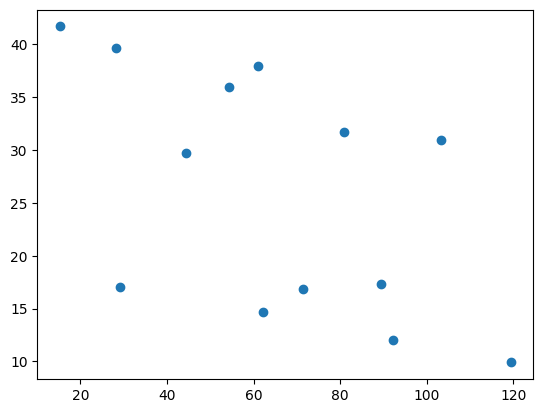

In [29]:
import matplotlib.pyplot as plt

plt.scatter(dataset['PSA'], dataset['Inh_value(%)'])

In [20]:
mols2grid.display(dataset, mol_col='mol', subset=['Inh_value(%)'], size=(100, 100))

## ② 물성 범위를 목표로 하는 RL 설정 만들기

각 물성이 저해제들의 `[min, max]` 범위 안에 들어오면 높은 점수를 주도록 **double_sigmoid** transform을 사용하거나 각 항목에 맞는 transform을 사용합니다. 여러 물성을 동시에 맞춰야 하므로 `geometric_mean`으로 합칩니다.

In [36]:
prior_filename = "/content/REINVENT4/priors/reinvent.prior"

components = f"""
[[stage.scoring.component]]
[stage.scoring.component.QED]
[[stage.scoring.component.QED.endpoint]]
name = "QED"
weight = 1

[[stage.scoring.component]]
[stage.scoring.component.TPSA]
[[stage.scoring.component.TPSA.endpoint]]
name = "TPSA"
weight = 0.5
transform.type = "reverse_sigmoid"
transform.high = 120
transform.low = 40
transform.k = 0.3
"""


config = f"""run_type = "staged_learning"
device = "cpu"
tb_logdir = "tb_trxr"
json_out_config = "_trxr.json"

[parameters]
prior_file = "{prior_filename}"
agent_file = "{prior_filename}"
summary_csv_prefix = "trxr_stage"
batch_size = 64
use_checkpoint = false

[learning_strategy]
type = "dap"
sigma = 128
rate = 0.0001

[diversity_filter]
type = "IdenticalMurckoScaffold"
bucket_size = 25
minscore = 0.4

[[stage]]
chkpt_file = "trxr_stage.chkpt"
termination = "simple"
max_score = 0.8
min_steps = 10
max_steps = 30

[stage.scoring]
type = "geometric_mean"

[[stage.scoring.component]]
[stage.scoring.component.custom_alerts]
[[stage.scoring.component.custom_alerts.endpoint]]
name = "Alerts"
params.smarts = ["[*;r{{8-17}}]", "[#8][#8]", "[#6;+]", "[#16][#16]", "C#C"]

{components}"""

with open("/content/REINVENT4/trxr_staged.toml", "w") as f:
    f.write(config)


## ③ RL 실행 & 학습곡선

> ⏳ **주의:** Colab CPU에서는 시간이 걸립니다(수십 분). GPU 런타임이면 훨씬 빠릅니다. 시간이 부족하면 `max_steps`를 더 줄이거나 이 셀을 건너뛰세요.

In [37]:
%cd /content/REINVENT4
!python -m reinvent.Reinvent -l trxr.log /content/REINVENT4/trxr_staged.toml

/content/REINVENT4
2026-07-27 06:00:47.009078: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 06:00:47.124917: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


In [ ]:
# TrxR RL 학습 로그 — 학습 셀을 건너뛰었다면 받아옵니다
ensure("tb_trxr_0")

In [39]:
# 학습곡선 — 스텝이 지날수록 평균 점수가 오르면 물성 목표에 수렴하는 중
%tensorboard --logdir /content/REINVENT4/tb_trxr_0 --load_fast true

<IPython.core.display.Javascript object>

## ④ 생성 분자 sampling → 상위 10% 선별 → 저해제와 비교

학습한 agent(checkpoint)에서 분자를 sampling한 뒤, 각 분자가 목표 물성 범위에 얼마나 들어맞는지로 점수를 매겨 **상위 10%**를 선별합니다. 그리고 생성 분자의 물성 분포가 실제 13개 저해제와 얼마나 겹치는지 확인합니다.

In [ ]:
# sampling에는 학습된 체크포인트가 필요합니다.
# 위 RL 셀을 건너뛰었거나 시간이 부족했다면 미리 학습해 둔 체크포인트를 받아옵니다.
ensure("trxr_stage.chkpt")

In [40]:
# 학습한 agent에서 분자 생성
sampling_toml = """
run_type = "sampling"
device = "cpu"

[parameters]
model_file = "/content/REINVENT4/trxr_stage.chkpt"
output_file = "trxr_generated.csv"
num_smiles = 1000
unique_molecules = true
randomize_smiles = true
"""
with open("/content/REINVENT4/sampling_trxr.toml", "w") as f:
    f.write(sampling_toml)

!python -m reinvent.Reinvent -l sampling_trxr.log /content/REINVENT4/sampling_trxr.toml

2026-07-27 06:54:56.900766: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 06:54:57.087825: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [46]:
# 생성 분자 물성 계산 + "목표 범위 적합도(match)" 점수 → 상위 10%

global_scoring_parameters = """
run_type = "scoring"
json_out_config = "_scoring.json"
"""

parameters = """
[parameters]
smiles_file = "trxr_generated.csv"   # sampling된 분자 파일 경로
output_csv = "trxr_scoring.csv"
"""
scoring = """
[scoring]
type = "geometric_mean"

[[scoring.component]]
[scoring.component.GraphLength]
[[scoring.component.GraphLength.endpoint]]
name = "GraphLength" # 최장 경로의 결합(bond) 수
weight = 0.2
transform.type = "reverse_sigmoid"
transform.high = 40
transform.low = 20
transform.k = 0.5

[[scoring.component]]
[scoring.component.QED]
[[scoring.component.QED.endpoint]]
name = "QED" # 최장 경로의 결합(bond) 수
weight = 0.2

[[scoring.component]]
[scoring.component.MolecularWeight]
[[scoring.component.MolecularWeight.endpoint]]
name = "Molecular weight"  # user chosen name for output
weight = 0.2  # weight to fine-tune the relevance of this component

# A transform ensures that the output from the scoring component ranges
# from 0 to 1 to serve as a proper score.  Here we use a double sigmoid
# to transform weights into the range 200-500 a.u.
transform.type = "double_sigmoid"
transform.high = 500.0
transform.low = 200.0
transform.coef_div = 500.0
transform.coef_si = 20.0
transform.coef_se = 20.0

[[scoring.component]]
[scoring.component.TPSA]
[[scoring.component.TPSA.endpoint]]
name = "TPSA"
weight = 0.2
transform.type = "double_sigmoid"
transform.high = 140.0
transform.low = 0.0
transform.coef_div = 140.0
transform.coef_si = 20.0
transform.coef_se = 20.0



"""
scoring_conf = global_scoring_parameters + parameters + scoring
with open("trxr_scoring.toml", "w") as tf:
    tf.write(scoring_conf)


In [47]:
!python -m reinvent.Reinvent -l scoring.log /content/REINVENT4/trxr_scoring.toml

2026-07-27 07:09:47.491297: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-27 07:09:47.581590: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Failed to find the pandas get_adjustment() function to patch
Failed to patch pandas - PandasTools will have limited functionality


In [ ]:
# 앞의 sampling·scoring을 건너뛰었다면 미리 만들어 둔 결과 파일을 받아옵니다
ensure("trxr_generated.csv", "trxr_scoring.csv")

In [49]:
# 생성 분자 물성 계산 + "목표 범위 적합도(match)" 점수 → 상위 10%
gen = pd.read_csv("/content/REINVENT4/trxr_scoring.csv")

top10 = gen.sort_values("Score", ascending=False).head(int(len(gen) * 0.10)).reset_index(drop=True)
print(f"생성 {len(gen)}개 → 상위 10% = {len(top10)}개 (평균 적합도 {top10['Score'].mean():.2f})")
top10.head()

생성 984개 → 상위 10% = 98개 (평균 적합도 0.97)


,SMILES,SMILES_state,NLL,RDKit_SMILES (REINVENT),Score,GraphLength,QED,Molecular weight,TPSA,GraphLength (raw),QED (raw),Molecular weight (raw),TPSA (raw)
0,O=C(c1cccnc1)N1CCCC(Nc2ccc(F)cc2)C1,1,19.00,O=C(c1cccnc1)N1CCCC(Nc2ccc(F)cc2)C1,0.986573,0.999944,0.947520,0.999894,1.0,13.0,0.947520,299.349,45.23
1,Cc1ccccc1NC(=O)CN1C(=O)COc2ccccc21,1,21.49,Cc1ccccc1NC(=O)CN1C(=O)COc2ccccc21,0.986079,0.999982,0.945619,0.999860,1.0,11.0,0.945619,296.326,58.64
2,CS(=O)(=O)c1ccc(Cl)c(NC(=O)c2ccco2)c1,1,22.09,CS(=O)(=O)c1ccc(Cl)c(NC(=O)c2ccco2)c1,0.985878,0.999994,0.944801,0.999897,1.0,9.0,0.944801,299.735,76.38
3,CCc1ccc(NC(=O)CN2C(=O)CCc3ccccc32)cc1,1,22.79,CCc1ccc(NC(=O)CN2C(=O)CCc3ccccc32)cc1,0.985385,0.999944,0.942904,0.999954,1.0,13.0,0.942904,308.381,49.41
4,N#Cc1ccc(N=c2nc(OC3CCCCC3)nc[nH]2)cc1,1,25.02,N#Cc1ccc(N=c2nc(OC3CCCCC3)nc[nH]2)cc1,0.985245,0.999900,0.942511,0.999846,1.0,14.0,0.942511,295.346,86.95


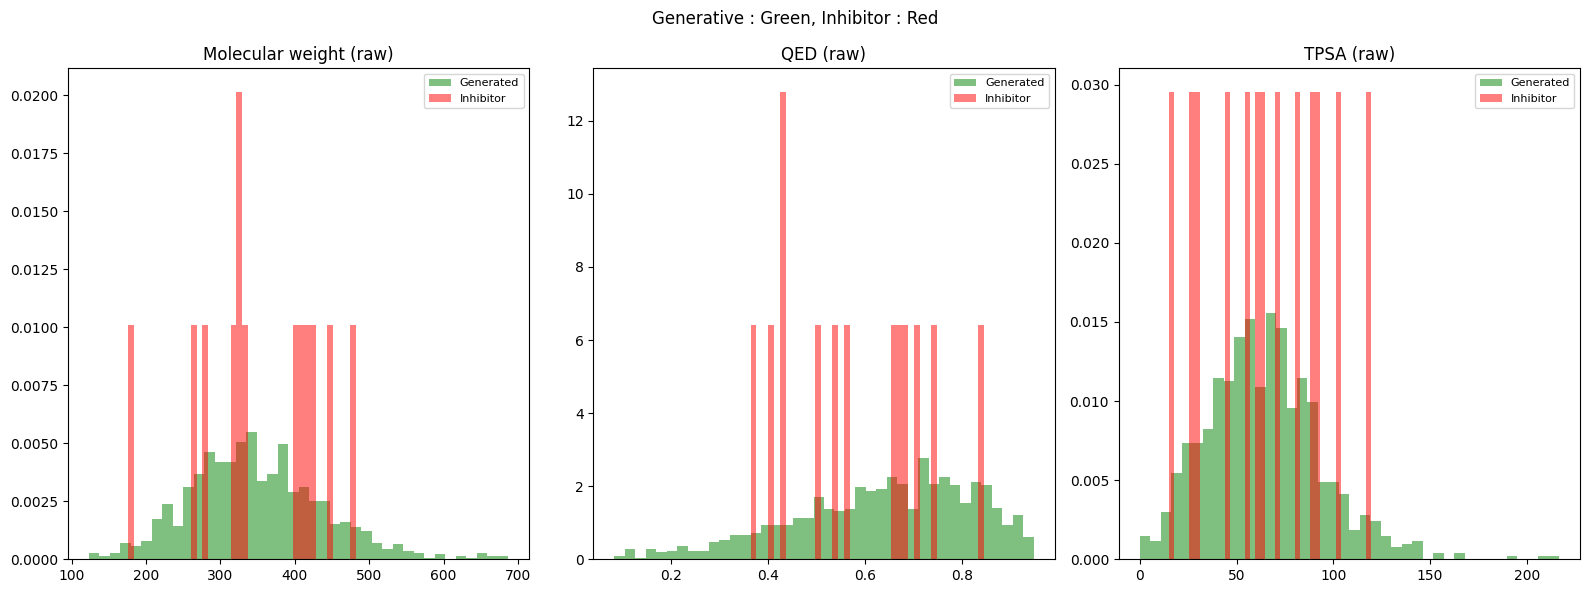

In [56]:
# 생성 분자 vs 13개 저해제 — 물성 분포 비교
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
cols = [("Molecular weight (raw)", "MW"), ("QED (raw)", "QED"), ("TPSA (raw)","PSA")]
for ax, (col, ref_col) in zip(axes.ravel(), cols):
    ax.hist(gen[col], bins=40, alpha=0.5, density=True, color="green", label="Generated")
    ax.hist(dataset[ref_col], bins=40, alpha=0.5, color = "red", density=True, label="Inhibitor")
    ax.set_title(col); ax.legend(fontsize=8)
plt.suptitle("Generative : Green, Inhibitor : Red")
plt.tight_layout(); plt.show()

In [58]:
# 상위 10% 분자 구조 보기
import mols2grid
top10 = top10.copy()
top10["mol"] = [Chem.MolFromSmiles(s) for s in top10["SMILES"]]
mols2grid.display(top10, mol_col="mol",
                  subset=["Score", "Molecular weight (raw)", "QED (raw)"],
                  transform={"Score": lambda x: f"{x:.2f}",
                             "Molecular weight (raw)":    lambda x: f"{x:.0f}",
                             "QED (raw)": lambda x: f"{x:.1f}"},
                  n_items_per_page=12, size=(200, 200))

### 🎯 이제 여러분 차례

이 예시는 **물성 프로파일 매칭**으로 접근했습니다. 다음을 바꿔가며 직접 실험해 보세요:

- **목표 물성을 조정** — QED·방향족 고리 수(`NumAromaticRings`) 등을 추가하거나, 범위를 좁혀 더 까다롭게 만들기
- **Transfer Learning으로 확장** — 위에서 선별한 상위 10% 분자(또는 13개 저해제)로 모델을 fine-tune해 타깃 화학공간에 더 초점 맞추기 (과제 원문의 마지막 단계, 상단 transfer_learning 예시 참고)


> 정답은 하나가 아닙니다. reward 컴포넌트·weight·transform 범위를 바꿔가며 생성 분자가 어떻게 달라지는지 관찰하는 것이 이 실습의 핵심입니다.
